In [1]:
%matplotlib inline

In [2]:
import pandas
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from matplotlib import animation, rc
from IPython.display import HTML

In [3]:
fname = '../data/eye_tracking/raw/KFD1.txt'
df = pandas.read_table(fname)

In [4]:
df.head()

,trial,buf_index,pos_time,pos_x,pos_y,pup_time,pup_diameter,marker
0,1,1,2433,13.056278,-9.549029,2433,4.375438,0
1,1,2,2447,12.585640,-23.112649,2447,4.280790,0
2,1,3,2450,12.279797,-24.893367,2450,4.263669,0
3,1,4,2453,11.317062,-23.571532,2453,4.268221,0
4,1,5,2457,10.681858,-24.828672,2457,4.272300,0


In [5]:
fragment = df[df.trial == 1]

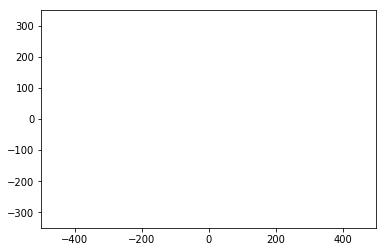

In [6]:
fig, ax = plt.subplots()
ax.set_xlim(-500, 500)
ax.set_ylim(-350, 350)
line, = ax.plot([], [], lw=2)

In [7]:
# initialization function: plot the background of each frame
def init():
    line.set_data([], [])
    return (line,)

In [8]:
# animation function. This is called sequentially
step = 10
def animate(i):
    x = fragment.pos_x[:step*i]
    y = fragment.pos_y[:step*i]
    line.set_data(x, y)
    return (line,)

In [9]:
n_frames = int(fragment.pos_x.shape[0]/step)
anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=n_frames, interval=20, blit=True)
HTML(anim.to_jshtml())